# COGNIFYZ TECHNOLOGIES - DATA SCIENCE INTERNSHIP PROJECT

### Project Name - Restaurant Data Analysis & Predictive Modeling
### Project Type - EDA
### Intern Name - Aditi Ganpat Khade 

# Level 3 Tasks :-

## ******************************* Import Libraries *******************************

In [5]:
# Importing Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib
%matplotlib inline
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Ignore all warnings
import warnings
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## ******************************* Loading Dataset *******************************

In [9]:
# Load Dataset from github repository
df = pd.read_csv(r'C:\Users\Administrator\Desktop\Cognifyz Technologies\Project\Dataset .csv')

In [11]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [13]:
# Drop duplicates
df = df.drop_duplicates()

# Handle missing values
df['Cuisines'] = df['Cuisines'].fillna('Unknown')
df = df.dropna(subset=['Aggregate rating'])

# Encode binary columns safely
binary_cols = ['Has Table booking', 'Has Online delivery']

for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Feature engineering
df['Name Length'] = df['Restaurant Name'].fillna('').astype(str).str.len()
df['Address Length'] = df['Address'].fillna('').astype(str).str.len()

print("Preprocessing complete.")
print(f"Dataset shape after preprocessing: {df.shape}")

Preprocessing complete.
Dataset shape after preprocessing: (9551, 23)


# ════════════════════════════════════════════════════
# LEVEL 3 │ TASK 1 – Predictive Modeling
# ════════════════════════════════════════════════════

In [15]:
# Text-based features 
df['Restaurant Name Length'] = df['Restaurant Name'].fillna('').astype(str).str.len()
df['Address Length'] = df['Address'].fillna('').astype(str).str.len()
df['Locality Name Length'] = df['Locality'].fillna('').astype(str).str.len()

# Cuisine count (handle NaN properly)
df['Cuisine Count'] = ( df['Cuisines'].fillna('').apply(lambda x: len([c for c in str(x).split(',') if c.strip() != ''])))

# Multi-cuisine flag
df['Is Multi-Cuisine'] = (df['Cuisine Count'] > 1).astype(int)

# Encode binary columns safely
for col in ['Has Table booking', 'Has Online delivery']:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'Yes': 1, 'No': 0})

In [17]:
# Keep only rated restaurants
df_model = df[df['Aggregate rating'] > 0].copy()

features = [
    'Price range',
    'Has Table booking',
    'Has Online delivery',
    'Name Length',
    'Address Length',
    'Cuisine Count',
    'Is Multi-Cuisine'
]

X = df_model[features]
y = df_model['Aggregate rating']

print("Dataset ready for modeling ✅")
print("Shape:", X.shape)

Dataset ready for modeling ✅
Shape: (7403, 7)


In [19]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Feature Scaling
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():

    # Use scaled data only for Linear Regression
    X_tr = X_train_sc if name == "Linear Regression" else X_train
    X_te = X_test_sc  if name == "Linear Regression" else X_test

    # Train
    model.fit(X_tr, y_train)

    # Predict
    y_pred = model.predict(X_te)

    # Metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # Store Results
    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "model": model
    }

    # Print Results
    print(f"\n{name}")
    print("-" * 30)
    print(f"Mean Absolute Error (MAE)  : {mae:.4f}")
    print(f"Root Mean Square Error (RMSE) : {rmse:.4f}")
    print(f"R-squared (R²)   : {r2:.4f}")


Linear Regression
------------------------------
Mean Absolute Error (MAE)  : 0.3990
Root Mean Square Error (RMSE) : 0.5026
R-squared (R²)   : 0.1831

Decision Tree
------------------------------
Mean Absolute Error (MAE)  : 0.4017
Root Mean Square Error (RMSE) : 0.5152
R-squared (R²)   : 0.1419

Random Forest
------------------------------
Mean Absolute Error (MAE)  : 0.4185
Root Mean Square Error (RMSE) : 0.5326
R-squared (R²)   : 0.0828


In [25]:
print("\n📉 Checking Overfitting:")

for name, model_info in results.items():
    model = model_info["model"]
    
    X_tr = X_train_sc if name == "Linear Regression" else X_train
    train_r2 = model.score(X_tr, y_train)
    test_r2  = model_info["R2"]
    
    print(f"{name}: Train R² = {train_r2:.4f} | Test R² = {test_r2:.4f}")


📉 Checking Overfitting:
Linear Regression: Train R² = 0.1800 | Test R² = 0.1831
Decision Tree: Train R² = 0.3277 | Test R² = 0.1419
Random Forest: Train R² = 0.8219 | Test R² = 0.0828


In [27]:
results_df = pd.DataFrame(results).T.drop(columns=["model"])
print("\n📊 Model Comparison:")
print(results_df.sort_values("R2", ascending=False).round(4))


📊 Model Comparison:
                        MAE      RMSE        R2
Linear Regression  0.398955  0.502638  0.183122
Decision Tree      0.401739  0.515162  0.141907
Random Forest      0.418497  0.532608  0.082802


In [29]:
# Select Best Model
best_name = max(results, key=lambda k: results[k]["R2"])
best_model = results[best_name]["model"]

print(f"\n🏆 Best Model: {best_name}")
print(f"Best R² Score: {results[best_name]['R2']:.4f}")


🏆 Best Model: Linear Regression
Best R² Score: 0.1831


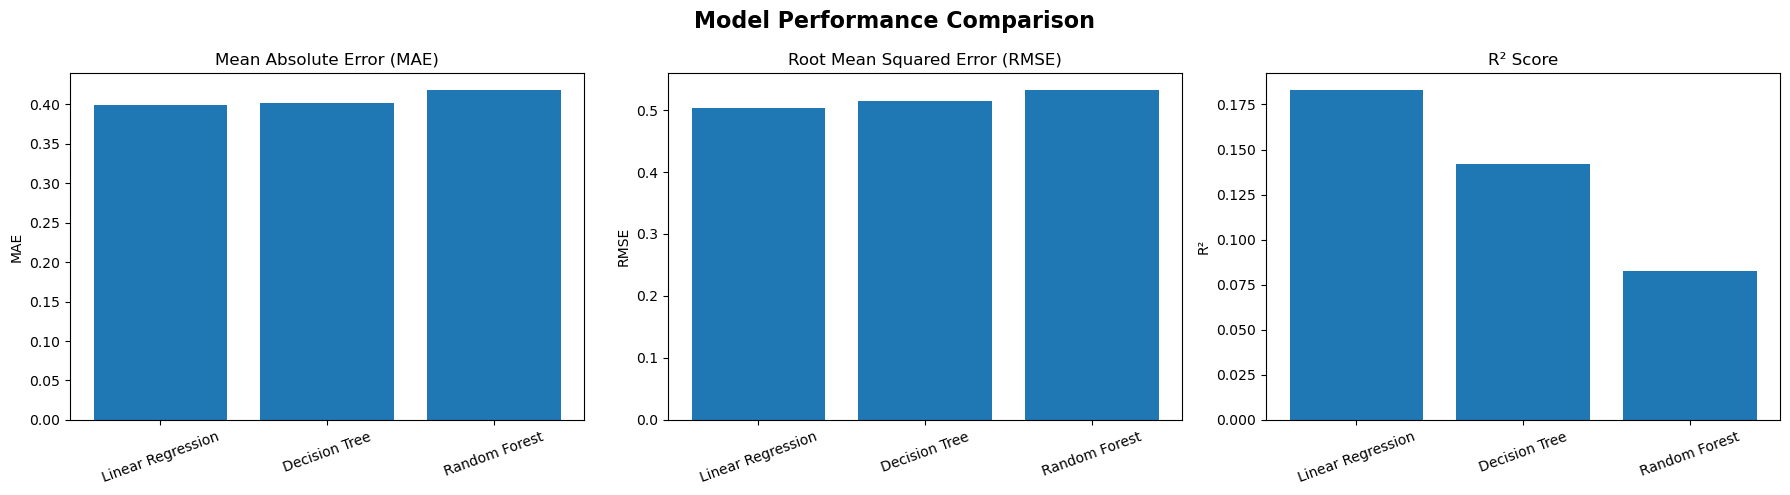

In [31]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).T.drop(columns=["model"])

# Sort by R2 score
results_df = results_df.sort_values("R2", ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold")

# ---- MAE ----
axes[0].bar(results_df.index, results_df["MAE"])
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=20)

# ---- RMSE ----
axes[1].bar(results_df.index, results_df["RMSE"])
axes[1].set_title("Root Mean Squared Error (RMSE)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=20)

# ---- R2 ----
axes[2].bar(results_df.index, results_df["R2"])
axes[2].set_title("R² Score")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════
# LEVEL 3 │ TASK 2 – Customer Preference Analysis
# ════════════════════════════════════════════════════

In [33]:
#step 1: Create cuisine dataframe
cuisine_df = df[['Cuisines', 'Aggregate rating', 'Votes']].copy()

# Remove unrated restaurants
cuisine_df = cuisine_df[cuisine_df['Aggregate rating'] > 0]

# Split multiple cuisines
cuisine_df['Cuisines'] = cuisine_df['Cuisines'].astype(str).str.split(', ')

# Explode
cuisine_exploded = cuisine_df.explode('Cuisines')

# Clean whitespace
cuisine_exploded['Cuisines'] = cuisine_exploded['Cuisines'].str.strip()



Top 10 Highest Rated Cuisines:
Cuisines
Sunda         4.900000
B�_rek        4.700000
Taiwanese     4.650000
Persian       4.600000
Ramen         4.500000
Dim Sum       4.466667
Hawaiian      4.412500
Bubble Tea    4.400000
D�_ner        4.400000
Curry         4.400000
Name: Aggregate rating, dtype: float64


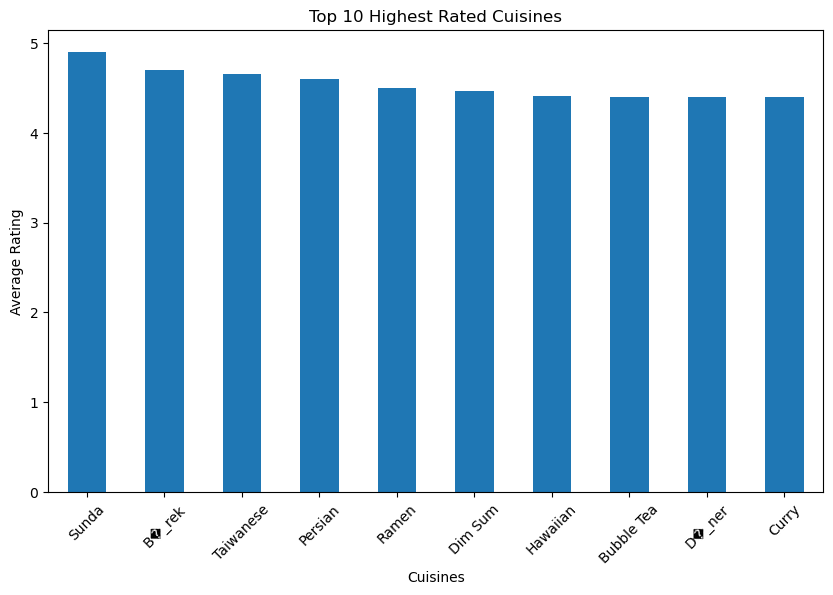

In [35]:
avg_rating = ( cuisine_exploded.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False))

print("\nTop 10 Highest Rated Cuisines:")
print(avg_rating.head(10))

plt.figure(figsize=(10,6))
avg_rating.head(10).plot(kind='bar')
plt.title("Top 10 Highest Rated Cuisines")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()


Top 10 Most Popular Cuisines (Based on Votes):
Cuisines
North Indian    595194
Chinese         363890
Italian         329230
Continental     288213
Fast Food       183665
American        183106
Cafe            177494
Mughlai         151784
Desserts        105781
Asian           104298
Name: Votes, dtype: int64


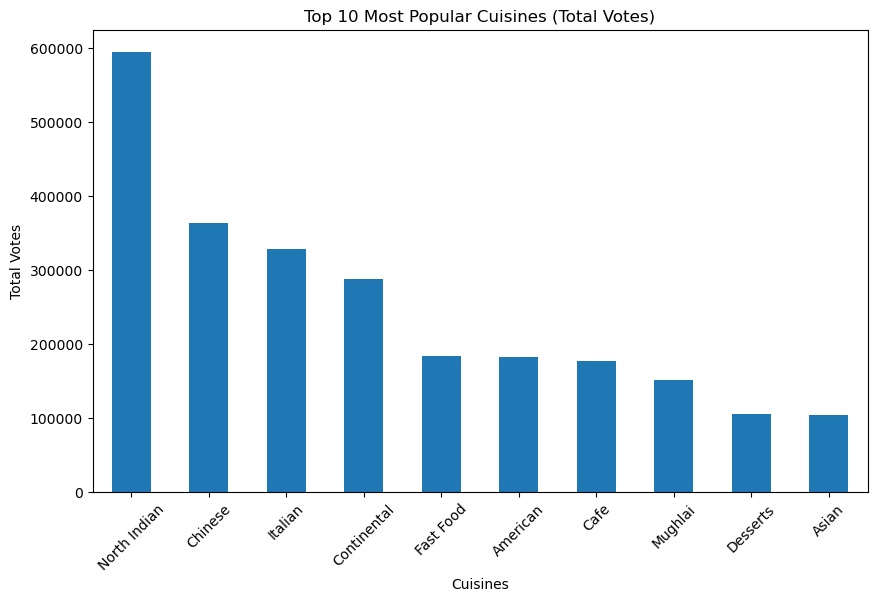

In [37]:
total_votes = ( cuisine_exploded.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False))

print("\nTop 10 Most Popular Cuisines (Based on Votes):")
print(total_votes.head(10))

plt.figure(figsize=(10,6))
total_votes.head(10).plot(kind='bar')
plt.title("Top 10 Most Popular Cuisines (Total Votes)")
plt.ylabel("Total Votes")
plt.xticks(rotation=45)
plt.show()

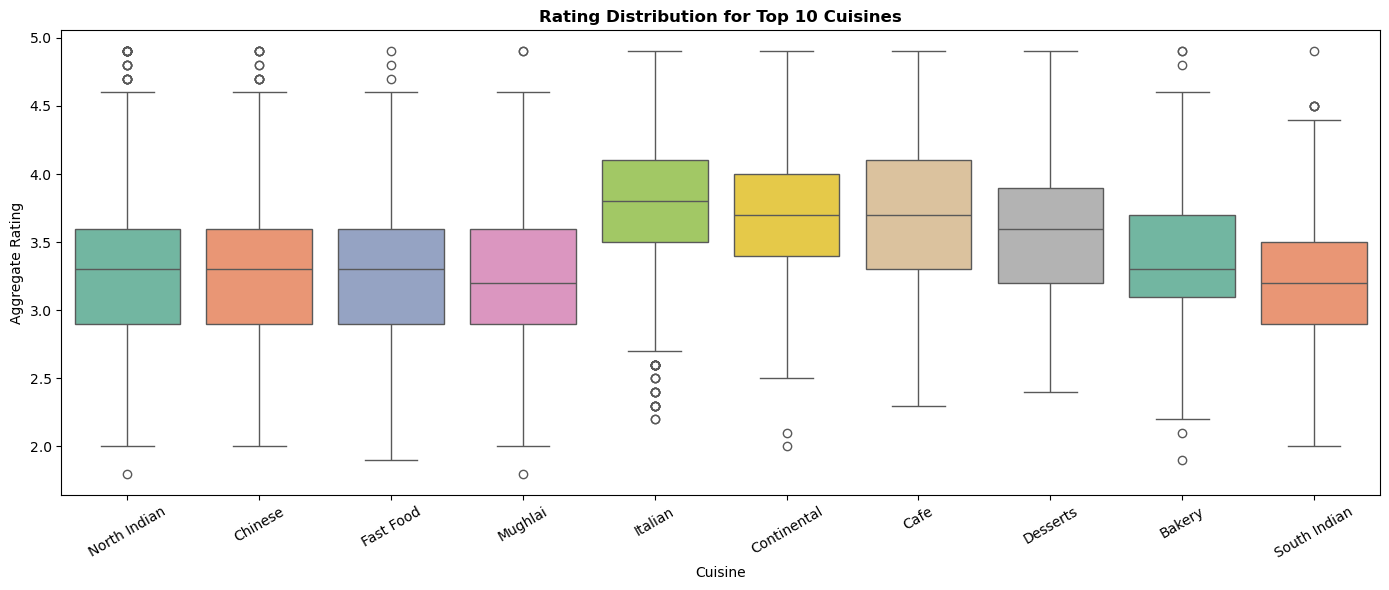

In [39]:
top10_cuisines = ( cuisine_exploded['Cuisines'].value_counts().head(10).index.tolist())

cuisine_box_df = cuisine_exploded[cuisine_exploded['Cuisines'].isin(top10_cuisines)]

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot( data=cuisine_box_df,x='Cuisines',y='Aggregate rating',palette='Set2',order=top10_cuisines,ax=ax)

ax.set_title("Rating Distribution for Top 10 Cuisines", fontweight='bold')
ax.set_xlabel("Cuisine")
ax.set_ylabel("Aggregate Rating")
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════
# LEVEL 3 │ TASK 3 – Data Visualization
# ════════════════════════════════════════════════════

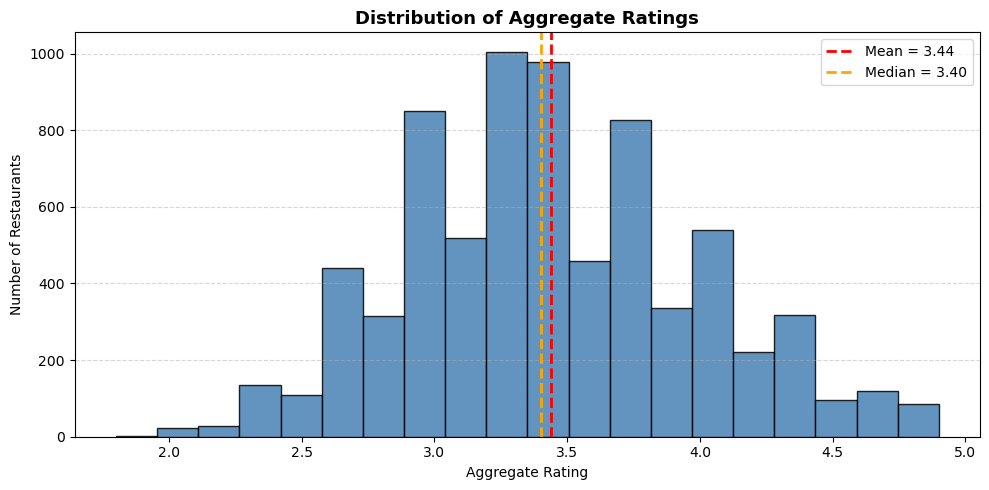

In [41]:
# Ensure unrated restaurants are removed
rated_df = df[df['Aggregate rating'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram
ax.hist( rated_df['Aggregate rating'],bins=20,color='steelblue',edgecolor='black',alpha=0.85)

# Mean & Median
mean_rating = rated_df['Aggregate rating'].mean()
median_rating = rated_df['Aggregate rating'].median()

ax.axvline(mean_rating, color='red',
           linestyle='--', linewidth=2,
           label=f"Mean = {mean_rating:.2f}")

ax.axvline(median_rating, color='orange',
           linestyle='--', linewidth=2,
           label=f"Median = {median_rating:.2f}")

# Labels & Title
ax.set_title("Distribution of Aggregate Ratings",fontweight='bold', fontsize=13)
ax.set_xlabel("Aggregate Rating")
ax.set_ylabel("Number of Restaurants")

# Grid (makes it cleaner)
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend()
plt.tight_layout()
plt.show()

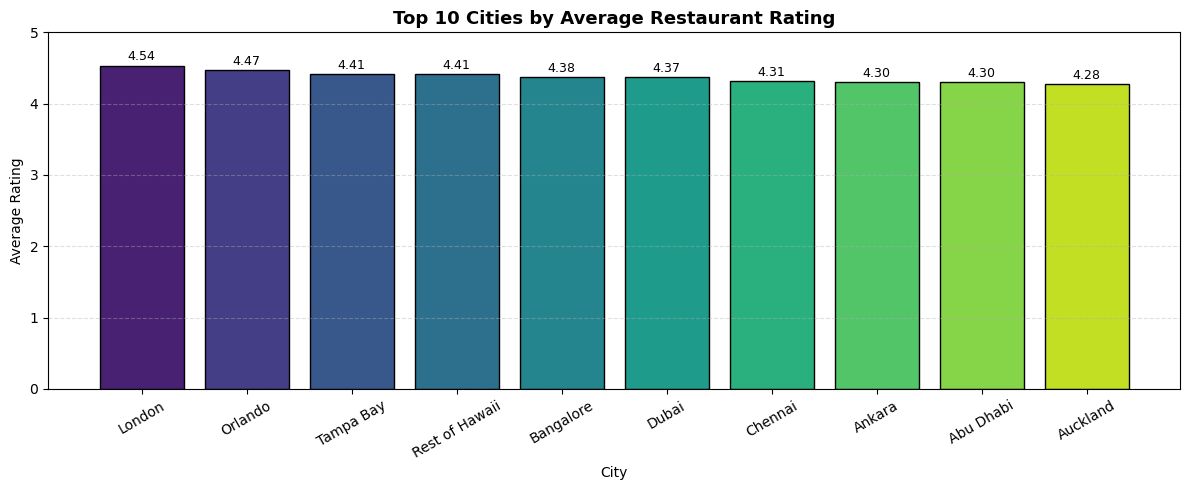

In [43]:
# Ensure rated data exists
rated_df = df[df['Aggregate rating'] > 0]

# ---- Top 10 Cities (Minimum 20 Restaurants) ----
top_cities = ( rated_df.groupby('City')['Aggregate rating'].agg(['mean', 'count']).query('count >= 20').sort_values('mean', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar( top_cities.index,top_cities['mean'],color=sns.color_palette("viridis", len(top_cities)),edgecolor='black')

ax.set_title("Top 10 Cities by Average Restaurant Rating",fontweight='bold', fontsize=13)
ax.set_xlabel("City")
ax.set_ylabel("Average Rating")
ax.set_ylim(0, 5)

ax.tick_params(axis='x', rotation=30)

# Add value labels above bars
for bar, val in zip(bars, top_cities['mean']):
    ax.text( bar.get_x() + bar.get_width()/2,bar.get_height() + 0.03,f"{val:.2f}",ha='center',va='bottom',fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

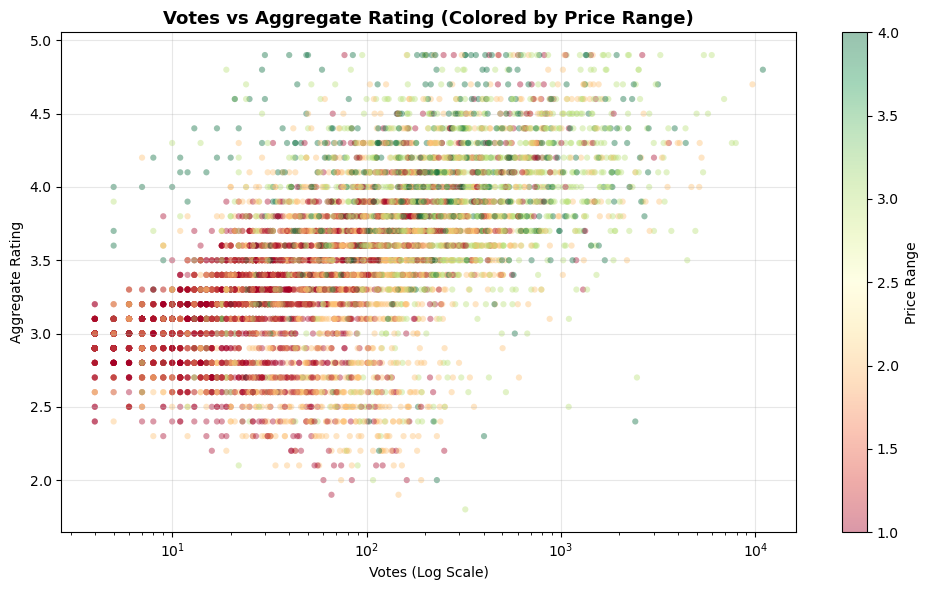

In [45]:
# Remove zero votes (log scale cannot handle 0)
scatter_df = rated_df[rated_df['Votes'] > 0]

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter( scatter_df['Votes'],scatter_df['Aggregate rating'],c=scatter_df['Price range'],cmap='RdYlGn',alpha=0.4,s=20,edgecolors='none')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Price Range")

ax.set_title("Votes vs Aggregate Rating (Colored by Price Range)",fontweight='bold', fontsize=13)
ax.set_xlabel("Votes (Log Scale)")
ax.set_ylabel("Aggregate Rating")
ax.set_xscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
print(rated_df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Name Length', 'Address Length', 'Restaurant Name Length',
       'Locality Name Length', 'Cuisine Count', 'Is Multi-Cuisine'],
      dtype='object')


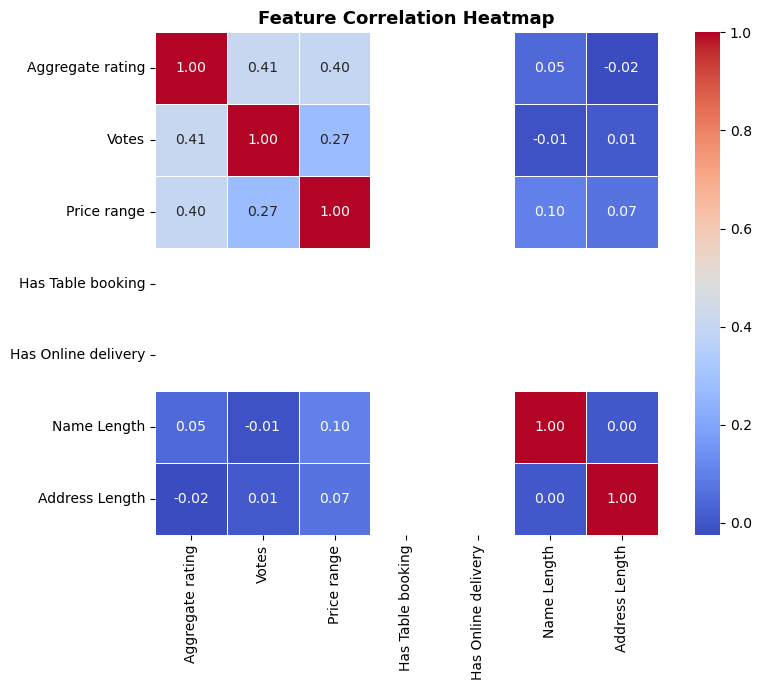

In [57]:
# Clean Yes/No columns
rated_df['Has Table booking'] = rated_df['Has Table booking'].astype(str).str.strip()
rated_df['Has Online delivery'] = rated_df['Has Online delivery'].astype(str).str.strip()

# Convert Yes/No to numeric
rated_df['Has Table booking'] = rated_df['Has Table booking'].map({'Yes':1, 'No':0})
rated_df['Has Online delivery'] = rated_df['Has Online delivery'].map({'Yes':1, 'No':0})

cols = [
    'Aggregate rating',
    'Votes',
    'Price range',
    'Has Table booking',
    'Has Online delivery',
    'Name Length',
    'Address Length'
]

corr = rated_df[cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)

plt.title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

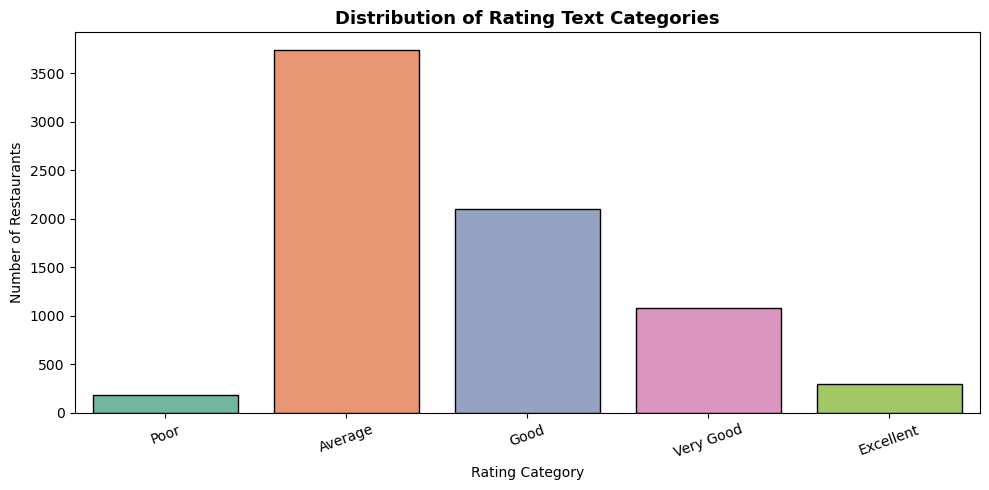

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))

rating_order = [
    'Poor',
    'Average',
    'Good',
    'Very Good',
    'Excellent'
]

sns.countplot( data=rated_df,x='Rating text',order=rating_order,palette='Set2',edgecolor='black',ax=ax)

ax.set_title("Distribution of Rating Text Categories",fontweight='bold', fontsize=13)
ax.set_xlabel("Rating Category")
ax.set_ylabel("Number of Restaurants")
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()